### ⚙️ Configuración Inicial

In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

---
### 🛠️ SECCIÓN 1 — PREPARACIÓN DE LOS DATOS

#### 1.1 — Carga del archivo tratado

In [16]:
# Cargar datos tratados de la Parte 1
df = pd.read_csv('datos_tratados.csv')

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head(3)

Dataset cargado: 7267 filas × 21 columnas


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [17]:
# Verificación general
print('Tipos de dato:')
print(df.dtypes)
print(f'\nValores nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Tipos de dato:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

Valores nulos:
Churn    224
dtype: int64


#### 1.2 — Estandarización de nombres de columnas

In [18]:
# Renombrar columnas anidadas al formato plano
df.columns = [
    col.replace('customer.', '')
       .replace('phone.', '')
       .replace('internet.', '')
       .replace('account.', '')
       .replace('Charges.', 'Charges_')
    for col in df.columns
]

print('Columnas renombradas:')
print(df.columns.tolist())

Columnas renombradas:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges_Monthly', 'Charges_Total']


#### 1.3 — Eliminación de Columnas Irrelevantes

In [19]:
# customerID no aporta información predictiva
df.drop(columns=['customerID'], inplace=True)

# Tratar nulos residuales en Charges_Total
df['Charges_Total'] = pd.to_numeric(df['Charges_Total'], errors='coerce')
df['Charges_Monthly'] = pd.to_numeric(df['Charges_Monthly'], errors='coerce')
df['Charges_Total'].fillna(df['Charges_Monthly'], inplace=True)
df.dropna(inplace=True)

print(f'Dataset limpio: {df.shape[0]} registros × {df.shape[1]} columnas')

Dataset limpio: 7043 registros × 20 columnas


#### 1.4 — Encoding de Variables Categóricas

In [20]:
# Separar variable objetivo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identificar columnas categóricas (excluyendo target)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Columnas categóricas a encodear ({len(cat_cols)}): {cat_cols}')

# Label Encoding para binarias / One-Hot para multi-clase
binary_cols   = [c for c in cat_cols if df[c].nunique() == 2]
multicat_cols = [c for c in cat_cols if df[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multicat_cols, drop_first=True)

# Convertir booleanos a int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'\nEncoding completo. Nuevas dimensiones: {df.shape}')
print('Columnas finales:')
print(df.columns.tolist())

Columnas categóricas a encodear (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Encoding completo. Nuevas dimensiones: (7043, 31)
Columnas finales:
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'Charges_Monthly', 'Charges_Total', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentM

#### 1.5 — Verificación de la Proporción de Churn

Distribución de Churn:
  No Churn:  5174 clientes (73.5%)
  Churn:  1869 clientes (26.5%)


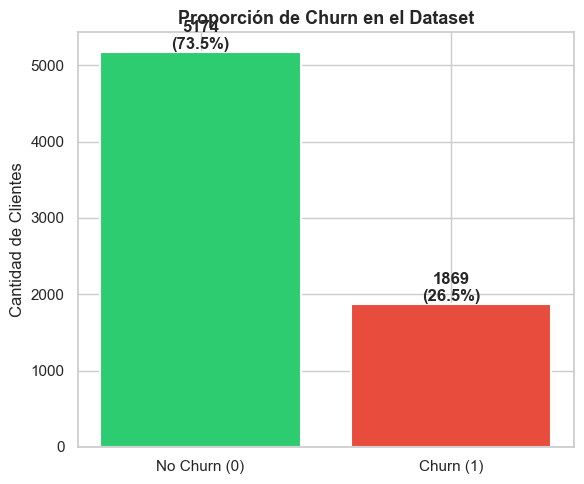

In [21]:
churn_dist = df['Churn'].value_counts()
churn_pct  = df['Churn'].value_counts(normalize=True) * 100

print('Distribución de Churn:')
for k, label in [(0, 'No Churn'), (1, 'Churn')]:
    print(f'  {label}: {churn_dist[k]:>5} clientes ({churn_pct[k]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(['No Churn (0)', 'Churn (1)'], churn_dist.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, churn_dist.values, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Proporción de Churn en el Dataset')
ax.set_ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()

#### 1.6 — Balanceo de Clases con SMOTE

> El dataset presenta desbalance (~26% Churn vs ~74% No Churn). Aplicamos **SMOTE** para sobremuestrear la clase minoritaria en el conjunto de entrenamiento.

In [22]:
# Separar features y target ANTES del balanceo
X = df.drop(columns=['Churn'])
y = df['Churn']

# División train/test (80/20 — estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar SMOTE solo sobre train
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Antes de SMOTE (train):', dict(pd.Series(y_train).value_counts()))
print('Después de SMOTE (train):', dict(pd.Series(y_train_bal).value_counts()))
print(f'\nTrain balanceado: {X_train_bal.shape[0]} muestras')
print(f'   Test (sin tocar):  {X_test.shape[0]} muestras')

Antes de SMOTE (train): {0: 4139, 1: 1495}
Después de SMOTE (train): {0: 4139, 1: 4139}

Train balanceado: 8278 muestras
   Test (sin tocar):  1409 muestras


#### 1.7 — Escalado de Variables Numéricas

In [23]:
scaler = StandardScaler()
num_cols = ['tenure', 'Charges_Monthly', 'Charges_Total']

X_train_bal[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test[num_cols]      = scaler.transform(X_test[num_cols])

print('Escalado aplicado a:', num_cols)

Escalado aplicado a: ['tenure', 'Charges_Monthly', 'Charges_Total']


---
### 🎯 SECCIÓN 2 — CORRELACIÓN Y SELECCIÓN DE VARIABLES

#### 2.1 — Mapa de Correlación General

Top 15 variables más correlacionadas con Churn:
tenure                                 -0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
StreamingTV_No internet service        -0.227890
TechSupport_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
DeviceProtection_No internet service   -0.227890
OnlineSecurity_No internet service     -0.227890
InternetService_No                     -0.227890
OnlineBackup_No internet service       -0.227890
Charges_Total                          -0.198347
Charges_Monthly                         0.193356
PaperlessBilling                        0.191825
Contract_One year                      -0.177820


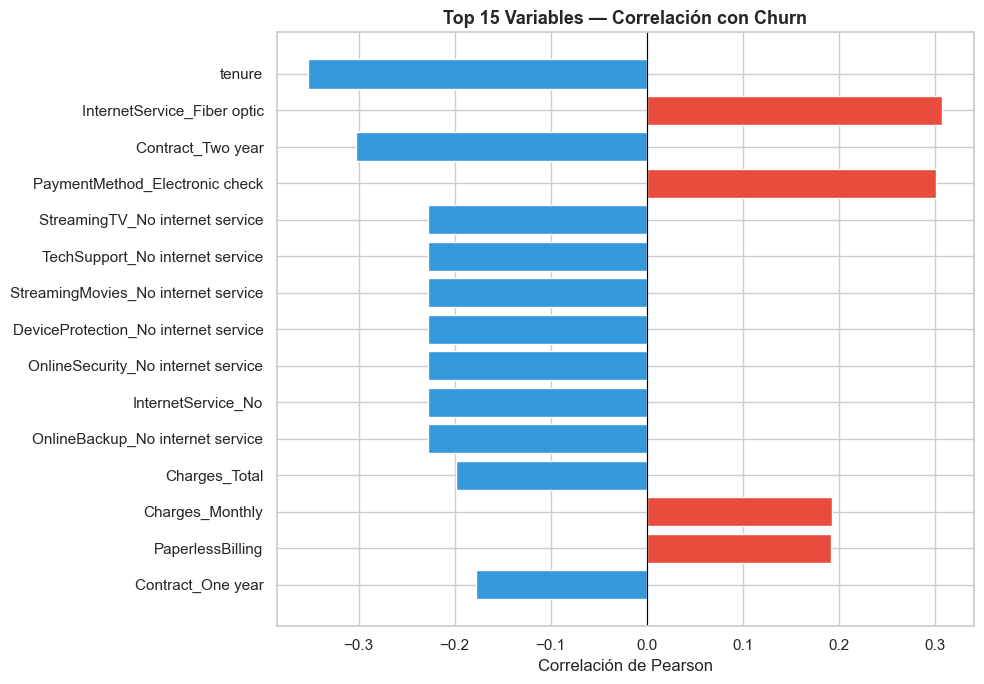

In [24]:
# Correlación de todas las variables con Churn (ordenado)
corr_churn = df.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print('Top 15 variables más correlacionadas con Churn:')
print(corr_churn.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_churn.head(15).values]
ax.barh(corr_churn.head(15).index[::-1],
        corr_churn.head(15).values[::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Variables — Correlación con Churn')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

#### 2.2 — Heatmap de Correlación (variables numéricas clave)

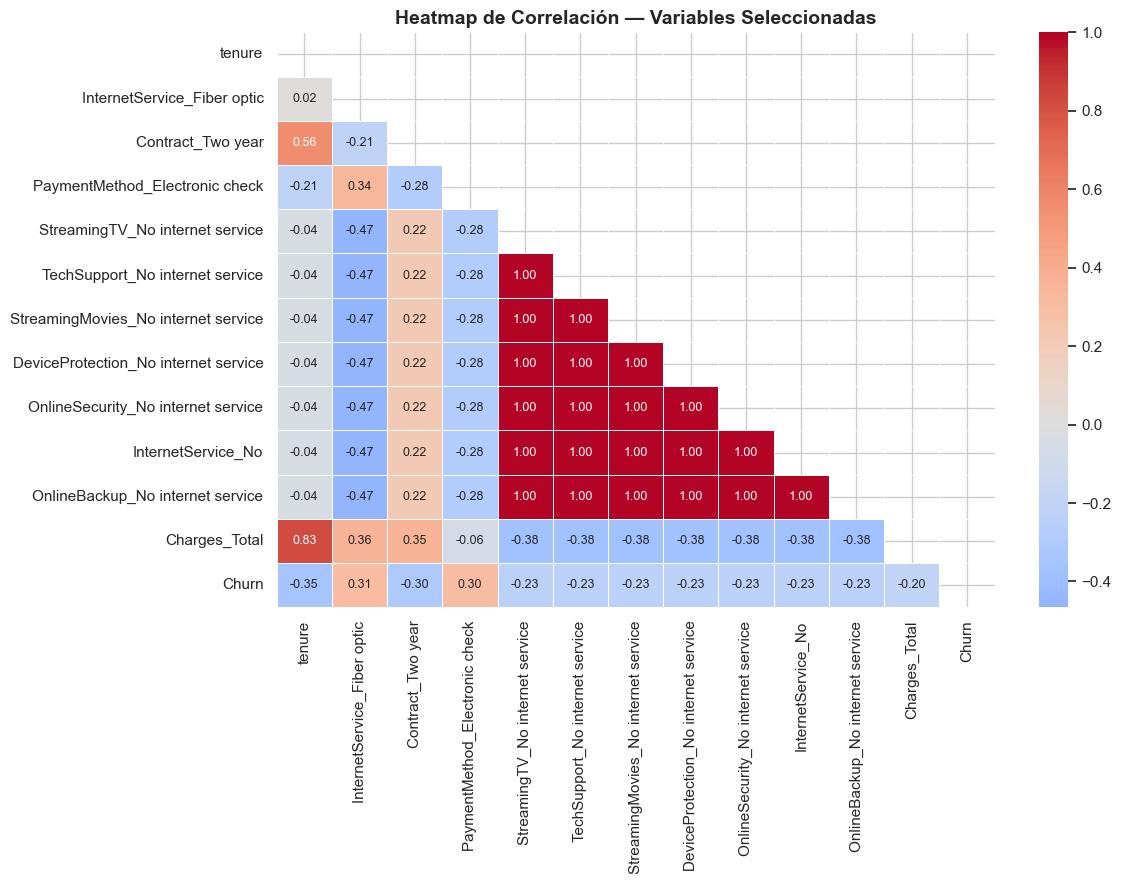

In [25]:
# Seleccionar top variables para heatmap
top_vars = corr_churn.head(12).index.tolist() + ['Churn']
corr_matrix = df[top_vars].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Heatmap de Correlación — Variables Seleccionadas', fontsize=14)
plt.tight_layout()
plt.show()

#### 2.3 — Análisis Dirigido: Variables Clave vs. Churn

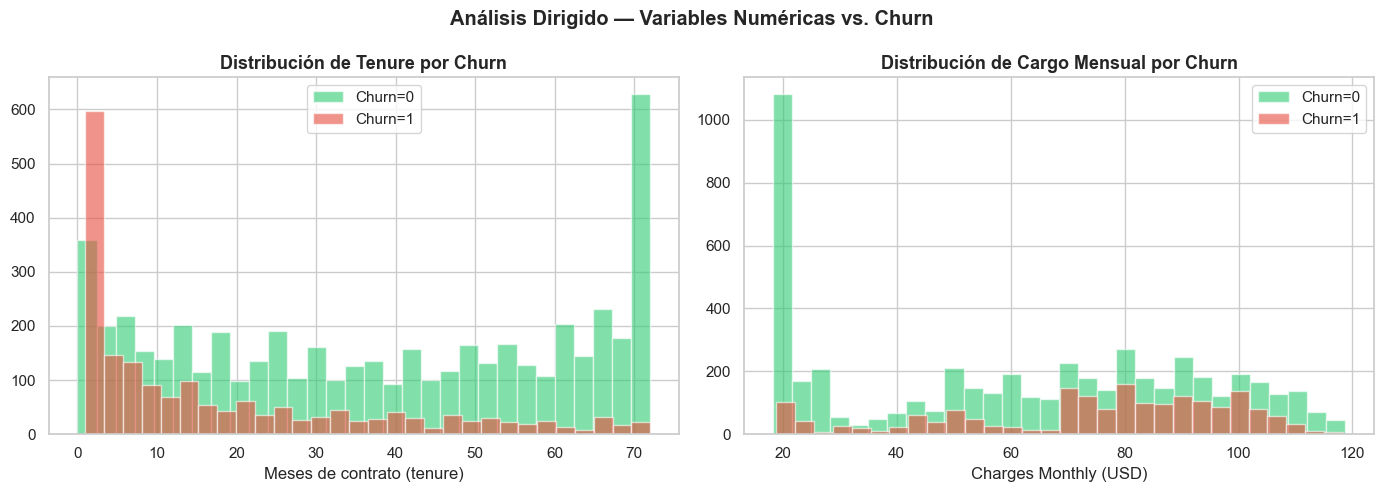

In [26]:
# Distribución de tenure y Charges_Monthly por clase Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    subset = df[df['Churn'] == label]
    axes[0].hist(subset['tenure'], bins=30, alpha=0.6, color=color,
                 label=f'Churn={label}')
    axes[1].hist(subset['Charges_Monthly'], bins=30, alpha=0.6, color=color,
                 label=f'Churn={label}')

axes[0].set_title('Distribución de Tenure por Churn')
axes[0].set_xlabel('Meses de contrato (tenure)')
axes[0].legend()

axes[1].set_title('Distribución de Cargo Mensual por Churn')
axes[1].set_xlabel('Charges Monthly (USD)')
axes[1].legend()

plt.suptitle('Análisis Dirigido — Variables Numéricas vs. Churn', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 🤖 SECCIÓN 3 — MODELADO PREDICTIVO

#### 3.1 — Definición de Modelos

Se entrenarán y compararán tres modelos:

| Modelo | Tipo | Ventaja Principal |
|---|---|---|
| Regresión Logística | Lineal | Interpretable, rápido |
| Árbol de Decisión | No lineal | Explícito, visual |
| Random Forest | Ensemble | Alta precisión, robusto |

In [27]:
# Definir modelos
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión':   DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   random_state=42, n_jobs=-1)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_bal, y_train_bal)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    resultados[nombre] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': acc,
        'auc': auc
    }
    print(f'{nombre:25} | Accuracy: {acc:.4f} | AUC-ROC: {auc:.4f}')

Regresión Logística       | Accuracy: 0.7715 | AUC-ROC: 0.8303
Árbol de Decisión         | Accuracy: 0.7580 | AUC-ROC: 0.8092
Random Forest             | Accuracy: 0.7644 | AUC-ROC: 0.8302


#### 3.2 — Evaluación: Reportes de Clasificación

In [28]:
for nombre, res in resultados.items():
    print("\n" + "="*55)
    print(f"{nombre}")
    print("="*55)
    print(classification_report(y_test, res['y_pred'],
                                  target_names=['No Churn', 'Churn']))


Regresión Logística
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409


Árbol de Decisión
              precision    recall  f1-score   support

    No Churn       0.87      0.78      0.83      1035
       Churn       0.53      0.69      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.76      0.77      1409


Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.69      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       

#### 3.3 — Matrices de Confusión

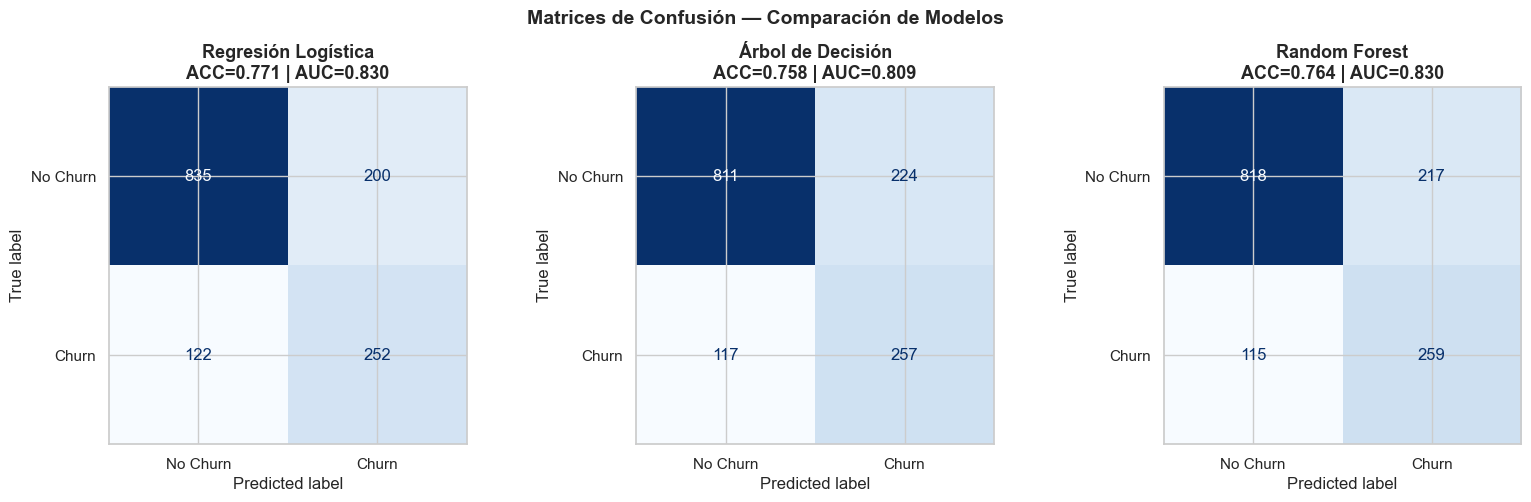

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}\nACC={res["accuracy"]:.3f} | AUC={res["auc"]:.3f}')

plt.suptitle('Matrices de Confusión — Comparación de Modelos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3.4 — Curvas ROC Comparativas

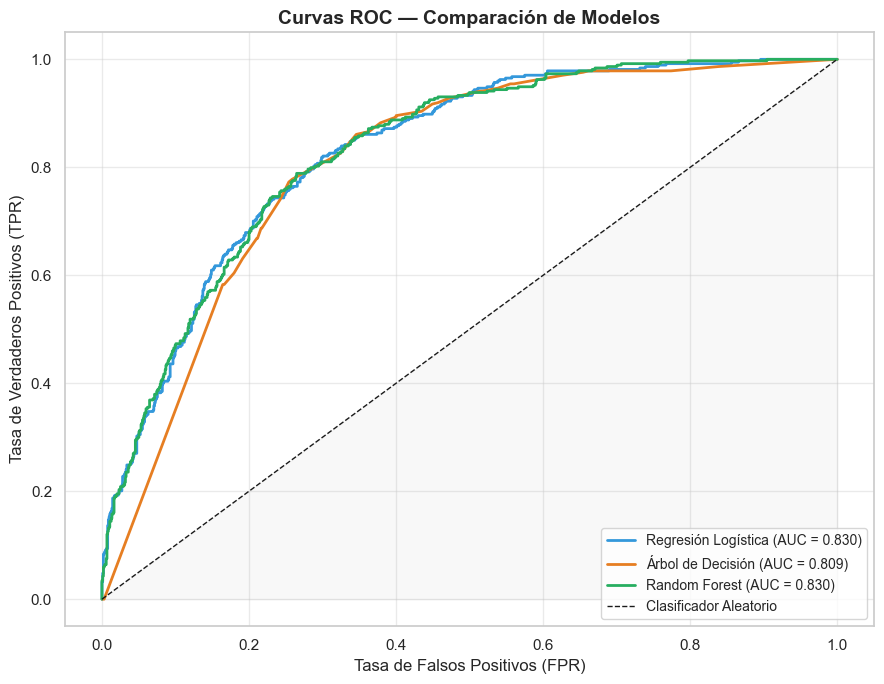

In [30]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498db', '#e67e22', '#27ae60']

for (nombre, res), color in zip(resultados.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{nombre} (AUC = {res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### 3.5 — Validación Cruzada (Cross-Validation)

Validación Cruzada (5-fold) — AUC-ROC:
--------------------------------------------------
  Regresión Logística       | Media: 0.8450 ± 0.0047
  Árbol de Decisión         | Media: 0.8207 ± 0.0087
  Random Forest             | Media: 0.8430 ± 0.0085


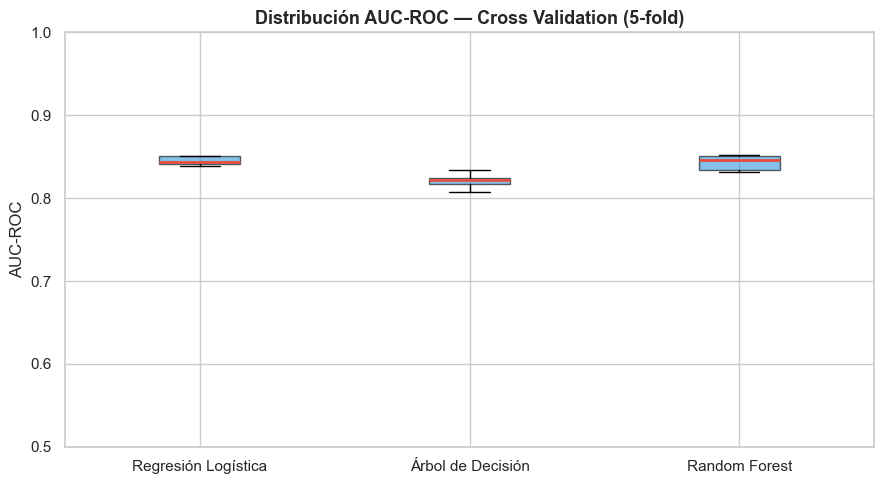

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Validación Cruzada (5-fold) — AUC-ROC:')
print('-'*50)

cv_results = {}
for nombre, res in resultados.items():
    scores = cross_val_score(res['modelo'], X, y, cv=cv,
                              scoring='roc_auc', n_jobs=-1)
    cv_results[nombre] = scores
    print(f'  {nombre:25} | Media: {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot comparativo
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6),
           medianprops=dict(color='#e74c3c', linewidth=2))
ax.set_title('Distribución AUC-ROC — Cross Validation (5-fold)')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

#### 3.6 — Tabla Resumen de Métricas

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

resumen_metricas = []
for nombre, res in resultados.items():
    resumen_metricas.append({
        'Modelo': nombre,
        'Accuracy': round(res['accuracy'], 4),
        'Precision (Churn)': round(precision_score(y_test, res['y_pred']), 4),
        'Recall (Churn)':    round(recall_score(y_test, res['y_pred']), 4),
        'F1-Score (Churn)':  round(f1_score(y_test, res['y_pred']), 4),
        'AUC-ROC':           round(res['auc'], 4),
        'CV AUC (media)':    round(cv_results[nombre].mean(), 4)
    })

df_metricas = pd.DataFrame(resumen_metricas).set_index('Modelo')
print('Tabla Comparativa de Métricas:')
display(df_metricas.style.highlight_max(color='#d4efdf').highlight_min(color='#fadbd8'))

Tabla Comparativa de Métricas:


,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),AUC-ROC,CV AUC (media)
Modelo,,,,,,
Regresión Logística,0.771500,0.557500,0.673800,0.610200,0.830300,0.845000
Árbol de Decisión,0.758000,0.534300,0.687200,0.601200,0.809200,0.820700
Random Forest,0.764400,0.544100,0.692500,0.609400,0.830200,0.843000


---
### 📋 SECCIÓN 4 — INTERPRETACIÓN Y CONCLUSIONES

#### 4.1 — Importancia de Variables (Random Forest)

Top 15 variables más importantes (Random Forest):
tenure                                   0.118903
Contract_Two year                        0.096511
Charges_Total                            0.084680
TechSupport_Yes                          0.084438
OnlineSecurity_Yes                       0.075982
Charges_Monthly                          0.068826
Contract_One year                        0.065807
Partner                                  0.043099
Dependents                               0.042990
OnlineBackup_Yes                         0.030188
OnlineSecurity_No internet service       0.028159
TechSupport_No internet service          0.025789
PaymentMethod_Credit card (automatic)    0.024878
InternetService_Fiber optic              0.024100
OnlineBackup_No internet service         0.021460


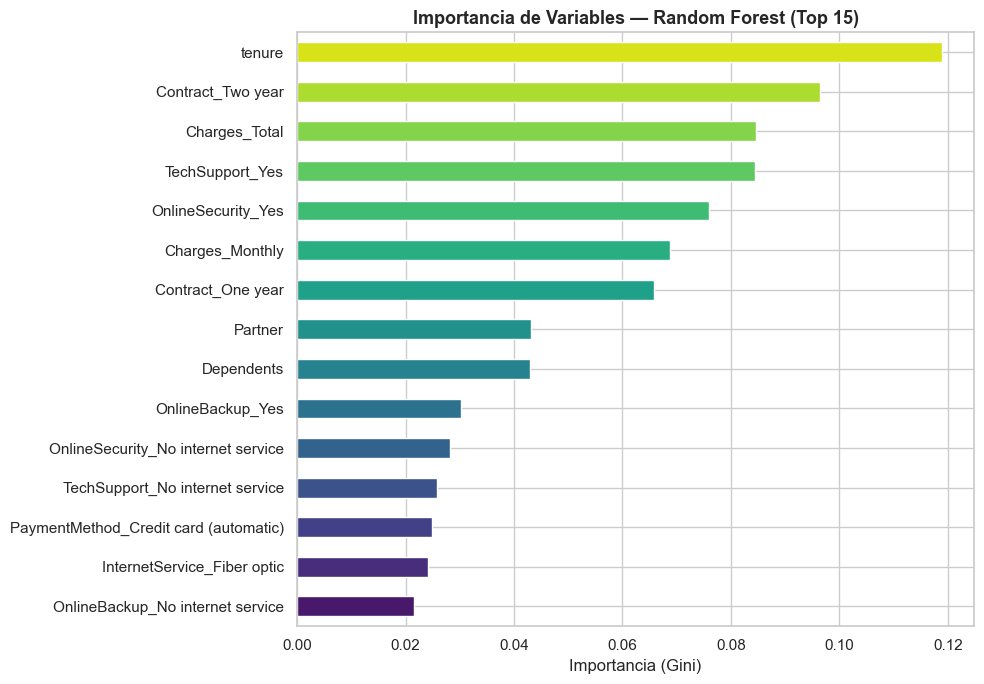

In [35]:
# Feature importance del mejor modelo esperado (Random Forest)
rf_model = resultados['Random Forest']['modelo']
importancias = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print('Top 15 variables más importantes (Random Forest):')
print(importancias.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
importancias.head(15)[::-1].plot(kind='barh', ax=ax,
                                   color=sns.color_palette('viridis', 15))
ax.set_title('Importancia de Variables — Random Forest (Top 15)')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

#### 4.2 — Coeficientes de Regresión Logística

Top 15 coeficientes — Regresión Logística:
PhoneService                            -5.600012
Charges_Monthly                          5.511861
InternetService_Fiber optic             -4.197186
StreamingMovies_Yes                     -1.958417
tenure                                  -1.895002
StreamingTV_Yes                         -1.847617
Contract_Two year                       -1.770384
TechSupport_Yes                         -1.750156
OnlineSecurity_Yes                      -1.687380
Charges_Total                            1.470234
OnlineBackup_Yes                        -1.425780
DeviceProtection_Yes                    -1.194743
MultipleLines_No phone service          -1.085845
Contract_One year                       -1.073591
PaymentMethod_Credit card (automatic)   -0.927235


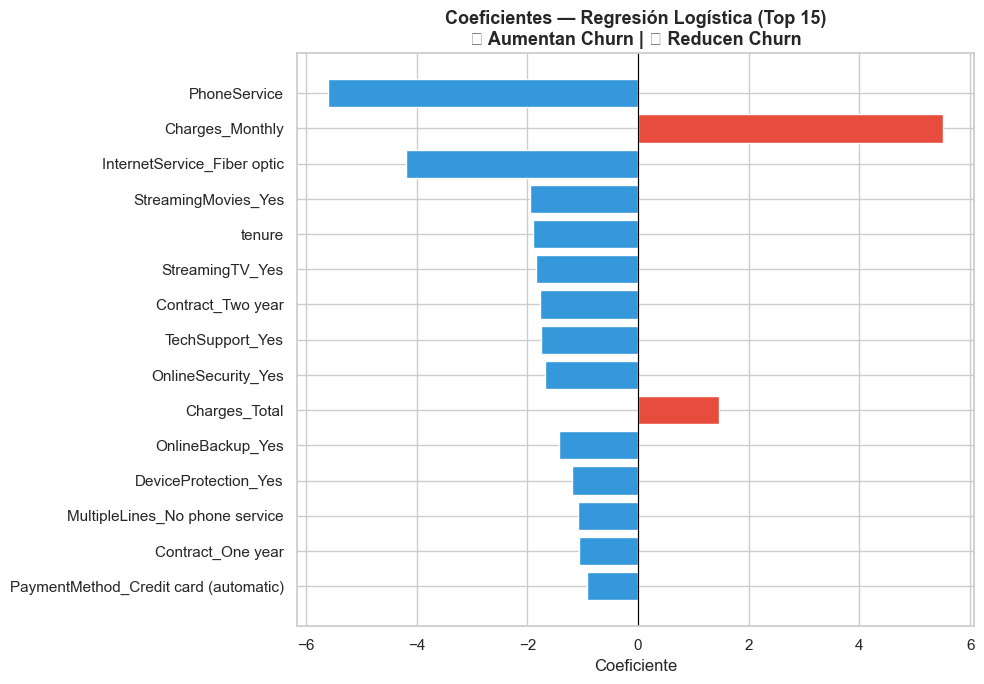

In [36]:
# Coeficientes de Regresión Logística (interpretabilidad)
rl_model = resultados['Regresión Logística']['modelo']
coeficientes = pd.Series(
    rl_model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

print('Top 15 coeficientes — Regresión Logística:')
print(coeficientes.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
top_coef = coeficientes.head(15)[::-1]
colors_coef = ['#e74c3c' if v > 0 else '#3498db' for v in top_coef.values]
ax.barh(top_coef.index, top_coef.values, color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Regresión Logística (Top 15)\n'
             '🔴 Aumentan Churn | 🔵 Reducen Churn')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

#### 4.3 — Conclusiones

---

##### Mejor Modelo → Regresión Logística
Gana por tener el mayor Accuracy (77.15%), el AUC-ROC más alto (0.8303), el mejor F1-Score para Churn (0.61) y la mayor estabilidad en validación cruzada (CV AUC = 0.845). Las curvas ROC confirman que Regresión Logística y Random Forest son casi equivalentes en discriminación, pero la logística se impone en interpretabilidad y consistencia.

##### Variables más influyentes
Se analizaron en conjunto los coeficientes de Regresión Logística y la importancia del Random Forest, encontrando dos grupos claros:
Aumentan el riesgo: Charges_Monthly alto, tenure bajo, InternetService_Fiber optic

Reducen el riesgo (factores protectores): Contract_Two year, TechSupport_Yes, OnlineSecurity_Yes, pago automático con tarjeta